GTZAN MUSIC GENRE CLASSIFICATION

[1] Extracting MFCC features from audio files...
Found 10 genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Processing 'blues' (100 files):


  blues: 100%|██████████| 100/100 [00:08<00:00, 12.31it/s]



Processing 'classical' (100 files):


  classical: 100%|██████████| 100/100 [00:08<00:00, 12.39it/s]



Processing 'country' (100 files):


...


Processing 'reggae' (100 files):


  reggae: 100%|██████████| 100/100 [00:11<00:00,  9.05it/s]



Processing 'rock' (100 files):


  rock: 100%|██████████| 100/100 [00:09<00:00, 10.10it/s]



Feature extraction complete!
Total samples: 9990
Feature shape: (40, 130, 3)
Labels shape: (9990,)

[2] Preparing train/val/test splits...

Dataset split:
  Train: (6993, 40, 130, 3) (6993 samples)
  Validation: (999, 40, 130, 3) (999 samples)
  Test: (1998, 40, 130, 3) (1998 samples)

[3] Creating CNN model...

MFCC CNN Architecture:
  Input shape: (3, 40, 130)
  Number of classes: 10
Using device: cuda

Model parameters: 423,562
Trainable parameters: 423,562

[4] TRAINING MODEL

Starting training for 300 epochs...
--------------------------------------------------------------------------------
Epoch [  1/300] | Train Loss: 1.8475, Acc: 0.3146 | Val Loss: 1.4218, Acc: 0.4374 | LR: 0.005000
Epoch [  2/300] | Train Loss: 1.6214, Acc: 0.3960 | Val Loss: 1.3167, Acc: 0.5195 | LR: 0.004999
Epoch [  3/300] | Train Loss: 1.5157, Acc: 0.4346 | Val Loss: 1.2511, Acc: 0.5345 | LR: 0.004999
Epoch [  4/300] | Train Loss: 1.4321, Acc: 0.4740 | Val Loss: 1.1291, Acc: 0.5926 | LR: 0.004998
Epoch [ 

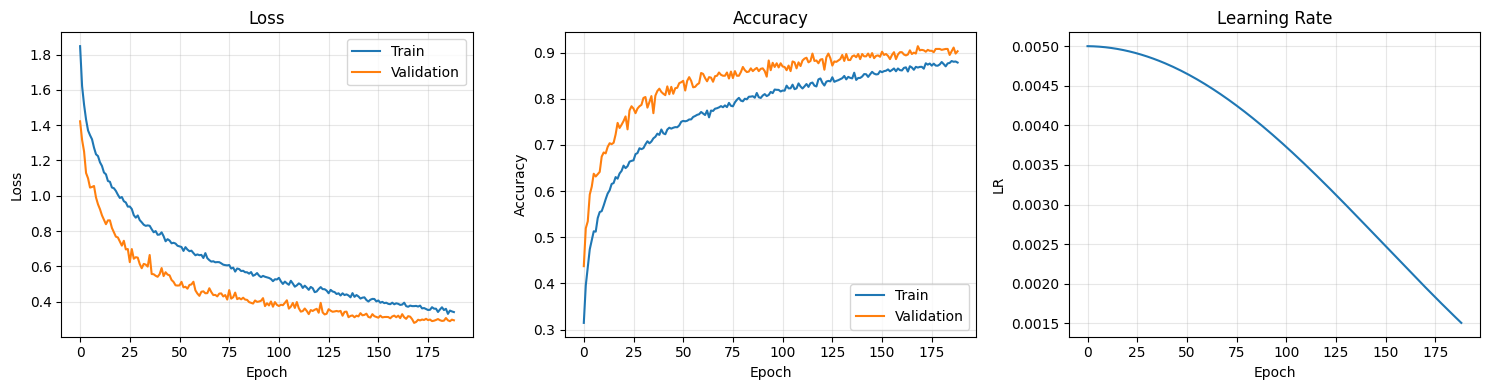


[6] FINAL EVALUATION

Test Accuracy: 0.8874

Classification Report:
              precision    recall  f1-score   support

       blues       0.93      0.92      0.92       200
   classical       0.95      0.95      0.95       200
     country       0.84      0.92      0.88       200
       disco       0.83      0.92      0.87       200
      hiphop       0.92      0.88      0.90       200
        jazz       0.92      0.93      0.93       198
       metal       0.83      0.98      0.90       200
         pop       0.94      0.83      0.88       200
      reggae       0.91      0.85      0.88       200
        rock       0.81      0.69      0.75       200

    accuracy                           0.89      1998
   macro avg       0.89      0.89      0.89      1998
weighted avg       0.89      0.89      0.89      1998


[7] SAMPLE PREDICTIONS

Sample 1:
  True: country
  Predicted: country (0.986)
  ✓ Correct

Sample 2:
  True: country
  Predicted: country (1.000)
  ✓ Correct

Sample 3:
 

In [8]:
import os
import librosa
import numpy as np
import math
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm  # For progress bars

warnings.filterwarnings('ignore')

class AudioProcessor:
    """Handles audio preprocessing for GTZAN dataset."""
    
    def __init__(self, dataset_path, sample_rate=22050):
        self.dataset_path = dataset_path
        self.sample_rate = sample_rate
        self.class_names = None
        
    def get_class_names(self):
        """Get genre names from directory structure."""
        self.class_names = sorted([d for d in os.listdir(self.dataset_path) 
                                  if os.path.isdir(os.path.join(self.dataset_path, d))])
        return self.class_names
    
    def extract_features(self, num_mfcc=40, n_fft=2048, hop_length=512, 
                        num_segment=10, target_time_steps=130):
        """
        Extract MFCC features from GTZAN dataset.
        
        Args:
            num_mfcc: Number of MFCC coefficients
            num_segment: Number of segments per 30-second track
            target_time_steps: Fixed time steps for all segments
        """
        
        # Get class names
        self.class_names = self.get_class_names()
        print(f"Found {len(self.class_names)} genres: {self.class_names}")
        
        data = {"features": [], "labels": []}
        samples_per_segment = int(self.sample_rate * 30 / num_segment)
        
        for label_idx, genre in enumerate(self.class_names):
            genre_path = os.path.join(self.dataset_path, genre)
            
            # Get all WAV files
            audio_files = sorted([f for f in os.listdir(genre_path) 
                                if f.endswith('.wav')])
            
            print(f"\nProcessing '{genre}' ({len(audio_files)} files):")
            
            for filename in tqdm(audio_files, desc=f"  {genre}"):
                file_path = os.path.join(genre_path, filename)
                
                try:
                    # Load audio
                    y, sr = librosa.load(file_path, sr=self.sample_rate)
                    
                    # Ensure exactly 30 seconds
                    target_length = self.sample_rate * 30
                    if len(y) < target_length:
                        y = np.pad(y, (0, target_length - len(y)), mode='constant')
                    else:
                        y = y[:target_length]
                    
                    # Process segments
                    for n in range(num_segment):
                        start = samples_per_segment * n
                        end = samples_per_segment * (n + 1)
                        segment = y[start:end]
                        
                        # Extract MFCCs
                        mfcc = librosa.feature.mfcc(
                            y=segment,
                            sr=sr,
                            n_mfcc=num_mfcc,
                            n_fft=n_fft,
                            hop_length=hop_length
                        )
                        
                        # Delta and Delta-Delta features
                        mfcc_delta = librosa.feature.delta(mfcc)
                        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
                        
                        # Stack features
                        features = np.stack([mfcc, mfcc_delta, mfcc_delta2], axis=-1)
                        
                        # Pad/truncate time dimension
                        if features.shape[1] < target_time_steps:
                            pad_width = ((0, 0), 
                                       (0, target_time_steps - features.shape[1]), 
                                       (0, 0))
                            features = np.pad(features, pad_width, mode='constant')
                        else:
                            features = features[:, :target_time_steps, :]
                        
                        data["features"].append(features)
                        data["labels"].append(label_idx)
                        
                except Exception as e:
                    print(f"\nError processing {filename}: {e}")
                    continue
        
        # Convert to numpy arrays
        X = np.array(data["features"], dtype=np.float32)  # Shape: (N, n_mfcc, time, 3)
        y = np.array(data["labels"], dtype=np.int64)
        
        print(f"\nFeature extraction complete!")
        print(f"Total samples: {X.shape[0]}")
        print(f"Feature shape: {X.shape[1:]}")  # (n_mfcc, time, 3)
        print(f"Labels shape: {y.shape}")
        
        return X, y, self.class_names


class MFCC_CNN(nn.Module):
    """CNN for MFCC spectrograms with delta features."""
    
    def __init__(self, input_shape, num_classes):
        super(MFCC_CNN, self).__init__()
        
        # Input shape: (channels, n_mfcc, time_steps)
        # channels = 3 (MFCC + delta + delta-delta)
        
        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.3),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),  # Only pool time dimension
            nn.Dropout2d(0.4),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)  # Global pooling
        )
        
        # Calculate flattened size
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
        # Print architecture
        print(f"\nMFCC CNN Architecture:")
        print(f"  Input shape: {input_shape}")
        print(f"  Number of classes: {num_classes}")
        
    def forward(self, x):
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


def prepare_datasets(X, y, test_size=0.2, val_size=0.1, random_state=42):
    """Split data into train, validation, and test sets."""
    
    # First split: train+val vs test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # Second split: train vs val
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_ratio,
        stratify=y_train_val, random_state=random_state
    )
    
    print(f"\nDataset split:")
    print(f"  Train: {X_train.shape} ({len(y_train)} samples)")
    print(f"  Validation: {X_val.shape} ({len(y_val)} samples)")
    print(f"  Test: {X_test.shape} ({len(y_test)} samples)")
    
    # Convert to PyTorch tensors
    # Note: PyTorch expects (batch, channels, height, width)
    # Our features are (n_mfcc, time, channels=3)
    # We need to permute to (batch, channels, n_mfcc, time)
    
    X_train = torch.FloatTensor(X_train).permute(0, 3, 1, 2)
    X_val = torch.FloatTensor(X_val).permute(0, 3, 1, 2)
    X_test = torch.FloatTensor(X_test).permute(0, 3, 1, 2)
    
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)
    
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'class_names': None  # Will be filled later
    }


def train_model(model, train_data, val_data, num_epochs, learning_rate, batch_size, patience):
    """Train the model with early stopping."""
    
    X_train, y_train = train_data
    X_val, y_val = val_data
    
    # Data loaders
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }
    
    # Early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"\nStarting training for {num_epochs} epochs...")
    print("-" * 80)
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
        
        # Metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = train_correct / train_total
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        
        # Update LR
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            torch.save(model.state_dict(), 'best_mfcc_model.pth')
        else:
            patience_counter += 1
        
        # Print progress
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] | '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | '
              f'LR: {current_lr:.6f}')
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    print("-" * 80)
    print(f"Training complete! Best val loss: {best_val_loss:.4f}")
    
    return history


def evaluate_model(model, test_data, class_names):
    """Evaluate model on test set."""
    
    X_test, y_test = test_data
    
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        
        y_pred = predicted.cpu().numpy()  
        y_true = y_test.cpu().numpy()     
        
        accuracy = (y_pred == y_true).mean()
        print(f"\nTest Accuracy: {accuracy:.4f}")
        
        # Per-class accuracy
        from sklearn.metrics import classification_report, confusion_matrix
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, 
                                   target_names=class_names))
    
    return accuracy


def plot_training_history(history):
    """Plot training and validation metrics."""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Validation')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'], label='Validation')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Learning rate
    axes[2].plot(history['lr'])
    axes[2].set_title('Learning Rate')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def main():
    
    # ===== CONFIGURATION =====
    DATASET_PATH = r"C:\Users\hrshe\OneDrive\Documents\Codes\NN\Data\genres_original"  
    
    # Feature extraction parameters
    NUM_MFCC = 40
    NUM_SEGMENTS = 10  # Each 30s track is divided into 10 segments each of length 3s
    TARGET_TIME_STEPS = 130
    
    # Training parameters
    NUM_EPOCHS = 300
    BATCH_SIZE = 32
    LEARNING_RATE = 0.005
    PATIENCE = 20  # Early stopping patience
    
    # ===== CHECK DATASET PATH =====
    if not os.path.exists(DATASET_PATH):
        print(f"ERROR: Dataset path not found: {DATASET_PATH}")
        print("Please update DATASET_PATH with your local path.")
        return
    
    print("=" * 80)
    print("GTZAN MUSIC GENRE CLASSIFICATION")
    print("=" * 80)
    
    # ===== STEP 1: EXTRACT FEATURES =====
    print("\n[1] Extracting MFCC features from audio files...")
    processor = AudioProcessor(DATASET_PATH)
    X, y, class_names = processor.extract_features(
        num_mfcc=NUM_MFCC,
        num_segment=NUM_SEGMENTS,
        target_time_steps=TARGET_TIME_STEPS
    )
    
    # ===== STEP 2: PREPARE DATASETS =====
    print("\n[2] Preparing train/val/test splits...")
    data = prepare_datasets(X, y)
    data['class_names'] = class_names
    
    # ===== STEP 3: CREATE MODEL =====
    print("\n[3] Creating CNN model...")
    input_shape = (3, NUM_MFCC, TARGET_TIME_STEPS)  # (channels, height, width)
    model = MFCC_CNN(input_shape, len(class_names))
    
    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model = model.to(device)
    
    # Move data to device
    for key in ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']:
        data[key] = data[key].to(device)
    
    # Print model info
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # ===== STEP 4: TRAIN MODEL =====
    print("\n" + "=" * 80)
    print("[4] TRAINING MODEL")
    print("=" * 80)
    
    train_data = (data['X_train'], data['y_train'])
    val_data = (data['X_val'], data['y_val'])
    
    history = train_model(
        model,
        train_data,
        val_data,
        num_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        patience=PATIENCE
    )
    
    # ===== STEP 5: PLOT RESULTS =====
    print("\n" + "=" * 80)
    print("[5] TRAINING HISTORY")
    print("=" * 80)
    plot_training_history(history)
    
    # ===== STEP 6: EVALUATE =====
    print("\n" + "=" * 80)
    print("[6] FINAL EVALUATION")
    print("=" * 80)
    
    test_data = (data['X_test'], data['y_test'])
    accuracy = evaluate_model(model, test_data, class_names)
    
    # ===== STEP 7: SAMPLE PREDICTIONS =====
    print("\n" + "=" * 80)
    print("[7] SAMPLE PREDICTIONS")
    print("=" * 80)
    
    model.eval()
    with torch.no_grad():
        indices = torch.randperm(len(data['X_test']))[:25]
        
        for i, idx in enumerate(indices):
            sample = data['X_test'][idx:idx+1]
            true_label = data['y_test'][idx].item()
            true_class = class_names[true_label]
            
            output = model(sample)
            probabilities = F.softmax(output, dim=1)
            pred_prob, pred_label = torch.max(probabilities, 1)
            
            pred_class = class_names[pred_label.item()]
            
            print(f"\nSample {i+1}:")
            print(f"  True: {true_class}")
            print(f"  Predicted: {pred_class} ({pred_prob.item():.3f})")
            print(f"  {'✓ Correct' if pred_label.item() == true_label else '✗ Incorrect'}")
    
    print("\n" + "=" * 80)
    print("PROCESS COMPLETE!")
    print(f"Final Test Accuracy: {accuracy:.4f}")
    print("=" * 80)


if __name__ == "__main__":
    main()